# Visualization

## Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import ast
import seaborn as sns
import json
import glob
import random
from copy import deepcopy
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap, to_rgb, to_rgba

import tensorflow as tf
from Fitting_algo_v4 import *
from ECM_impedance_v3 import *

Load Battery Metadata:

In [6]:
battery_json_file = "../EVC_EIS_Data/original_data/Battery_Info_DRT.json" # Check the path

with open(battery_json_file, "r") as f:
    BATTERY_METADATA = json.load(f)   # <--- this is now a dict
# Review current documented batteries
print(BATTERY_METADATA.keys())

dict_keys(['CELL009', 'CELL021', 'CELL077', 'CELL013', 'CELL042', 'CELL045', 'CELL050', 'CELL054', 'CELL076', 'CELL090', 'CELL096', 'CELL032', 'CELL070', 'CELL101'])


Load Battery EIS data:

In [80]:
def format_EIS(input_file):
    """
    Load EIS input csv and return a list of dictionary indexed by soc_index.

    Parameters
    ----------
    input_file : str
        csv file path of original EIS data, required to have columns ['time/s', 'I/mA', 'Ewe/V', 'freq/Hz', '|Z|/Ohm', 'Phase(Z)/deg', 'z cycle'].
    
    Returns
    ----------
    grouped_list : [{soc_dict}], a list of SOC dictionaries. soc_dict has attributes: freq, angular_freq, Z_mag, phase_deg, Z_real, Z_imag.
    """
    df = pd.read_csv(input_file)

    # Ensure relevant columns exist
    required = ['time/s', 'I/mA', 'Ewe/V', 'freq/Hz', '|Z|/Ohm', 'Phase(Z)/deg', 'z cycle']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Ensure numeric
    num_cols = ['time/s', 'I/mA', 'Ewe/V', 'freq/Hz', '|Z|/Ohm', 'Phase(Z)/deg', 'z cycle']
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    # Keep relevant cols and drop invalid rows
    df = (
        df[['freq/Hz', '|Z|/Ohm', 'Phase(Z)/deg', 'z cycle']]
        .dropna(subset=['freq/Hz', '|Z|/Ohm', 'Phase(Z)/deg', 'z cycle'])
        .query("`freq/Hz` != 0")
        .copy()
    )

    # Compute Z components
    phase_rad = np.deg2rad(df['Phase(Z)/deg'].to_numpy())
    Z_mag = df['|Z|/Ohm'].to_numpy()
    df['Z_mag'] = Z_mag
    df['Z_real'] = Z_mag * np.cos(phase_rad)
    df['Z_imag'] = Z_mag * np.sin(phase_rad)
    df['angular_freq'] = 2 * np.pi * df['freq/Hz'].to_numpy()
    df['soc_index'] = df['z cycle'].astype(int)

    # Group by z cycle and build list (index = soc_index)
    grouped_list = []
    for _, g in df.groupby('z cycle'):
        g_sorted = g.sort_values('freq/Hz', ascending=False)
        grouped_list.append({
            "freq": g_sorted['freq/Hz'].to_numpy(dtype=float),
            "angular_freq": g_sorted['angular_freq'].to_numpy(dtype=float),
            "Z_mag": g_sorted['Z_mag'].to_numpy(dtype=float),
            "phase_deg": g_sorted['Phase(Z)/deg'].to_numpy(dtype=float),
            "Z_real": g_sorted['Z_real'].to_numpy(dtype=float),
            "Z_imag": g_sorted['Z_imag'].to_numpy(dtype=float),
        })

    return grouped_list

In [ ]:
# Load EIS data
BATTERY_EISDATA = {}
for cell in BATTERY_METADATA.keys():
    celli_metadata = BATTERY_METADATA[cell]
    print(f"====== Loading EIS data for {cell}, temp={celli_metadata["temperature"]}, num_soh={celli_metadata["num_soh"]} =====")

    # Battery data retrieval
    for i in range(celli_metadata["num_soh"]):
        # Access SOH data
        soh_data = celli_metadata["soh"][i]
        print(f"SOH idex {i+1}, EIS data file: {soh_data["file"]}, Charge Capacity is {soh_data["capacity"]}")
        # Access SOC data
        print(f"---- This SOH state has {soh_data["num_soc"]} soc data: {soh_data["soc"]}")


    # Build EIS dictionary
    relative_path_to_data_dir = "../EVC_EIS_Data/original_data/" # Change to match data dir
    celli_EISdata = [] # list indexed by soh


    for i in range(celli_metadata["num_soh"]):
        soh_data = celli_metadata["soh"][i]
        EIS_filename = os.path.join(relative_path_to_data_dir, soh_data["file"])
        print(f"Loading file from {EIS_filename}")
        soh_dic = format_EIS(EIS_filename)
        celli_EISdata.append(soh_dic)
    
    BATTERY_EISDATA[cell] = celli_EISdata
    print(f"Finished.")
    

====== Loading EIS data for CELL009, temp=0, num_soh=4 =====
SOH idex 1, EIS data file: CELL009/ConvertFromMPR/GMJuly2022_CELL009_BOL_Characterization_R1_01_MB_CA6.csv, Charge Capacity is 3.58344999999088
---- This SOH state has 11 soc data: [0.915987837068381, 0.832495084994038, 0.748993864639892, 0.665491401570284, 0.582018296872806, 0.498495690345182, 0.414917580904707, 0.331370965171493, 0.247849014307924, 0.164266613065507, 0.0807002490578597]
SOH idex 2, EIS data file: CELL009/ConvertFromMPR/GMJuly2022_CELL009_EOLeis_2_P25C_15P0PSI_20230329_R0_CA1.csv, Charge Capacity is 2.23921999999413
---- This SOH state has 13 soc data: [0.936080033489535, 0.872124862270506, 0.808323435539052, 0.744363267339881, 0.680418786620041, 0.616507880933721, 0.552586984865072, 0.488689806902847, 0.424730693463131, 0.360836771505811, 0.296944550193152, 0.23298683475855, 0.169017110070977]
SOH idex 3, EIS data file: CELL009/ConvertFromMPR/GMJuly2022_CELL009_EIS_3d_P25C_15P0PSI_20230424_R0_CA3.csv, Charg

Load DRT Data:

In [ ]:
# CELL_TEMPDATA = {
#     "CELL009": {"temperature": 0}, # SOC 0-100
#     "CELL021": {"temperature": 0}, # SOC 0-100
#     "CELL077": {"temperature": 0}, # SOC 0-100

#     "CELL013": {"temperature": 25}, # SOC 50-100
#     "CELL042": {"temperature": 25}, # SOC 0-100
#     "CELL045": {"temperature": 25}, # SOC 20-80
#     "CELL050": {"temperature": 25}, # SOC 0-100
#     "CELL054": {"temperature": 25}, # SOC 50-100
#     "CELL076": {"temperature": 25}, # SOC 20-80
#     "CELL090": {"temperature": 25}, # SOC 0-100
#     "CELL096": {"temperature": 25}, # SOC 50-100

#     "CELL032": {"temperature": 45}, # SOC 0-100
#     "CELL070": {"temperature": 45}, # SOC 0-100
#     "CELL101": {"temperature": 45}, # SOC 0-100
# }

# def read_drt_data(data_dir, features, target):
#     data_list = []
#     for cell in CELL_TEMPDATA.keys():
#         file_path = os.path.join(data_dir, f"data_{cell}.csv")
#         if os.path.exists(file_path):
#             df = pd.read_csv(file_path).dropna(how="all") # Drop all NA rows (in case)
#             # df = df[df["soc"] > 0.25] #NOTE: filter and keep soc > 0.25 only
#             df["Cell"] = cell
#             df["temperature"] = CELL_TEMPDATA[cell]["temperature"]
#             if "temperature" in features:
#                 data_list.append(df[features + [target, "Cell"]])
#             else:
#                 data_list.append(df[features + [target, "Cell", "temperature"]])
#         else:
#             print(f"Warning: file not found for {cell}")

#     data_all = pd.concat(data_list, ignore_index=True)
#     print(f"Total samples: {len(data_all)}")
#     return data_all

In [ ]:
# DATA_DIR = "../EVC_EIS_Data/CELL_DRT_Data" # Relative Path
# FEATURES = ["R0", "R1", "R2", "R3"]
# TARGET = "Charge_capacity_Ah"

# data_all = read_drt_data(DATA_DIR, FEATURES, TARGET)

## ECM Fitting Result

Functions:

In [2]:
ECM_candidates_map = dict(zip(ECM_NAMES, ECM_IMPEDANCE_FUNCS))

def EIS_Nyquist_meas_vs_fit(battery_name, battery_metadata, battery_EISdata, soh_label, soc_label, ECM_name, est_result_file, select_est_ranks=[1], subtitle="", show_legend=True):

    soh_soc_eis = battery_EISdata[soh_label-1][soc_label-1]

    Z_meas_real = soh_soc_eis["Z_real"]
    Z_meas_negimag = -soh_soc_eis["Z_imag"]
    angular_freq = soh_soc_eis["angular_freq"]
    
    if os.path.exists(est_result_file):
        df = pd.read_csv(est_result_file)
        selected = df[df["trial_rank"].isin(select_est_ranks)].copy()
    else:
        print(f"[WARN] est_result_file not found: {est_result_file}")
    
    plt.figure(figsize=(8,8))
    plt.plot(Z_meas_real, Z_meas_negimag, marker="o", label="Lab Measurement")

    for _, row in selected.iterrows():
            rank = int(row["trial_rank"])

            est_params = ast.literal_eval(row["estimated_params"])
            Z_fit = ECM_candidates_map[ECM_name](est_params, angular_freq)
            plt.plot(Z_fit.real, -Z_fit.imag, linestyle="--", marker="*", label=f"ECM fit (rank={rank})")

    plt.xlabel("Re(Z) [Ω]")
    plt.ylabel("-Im(Z) [Ω]")
    if show_legend:
        plt.legend()

    cap = battery_metadata["soh"][soh_label - 1]["capacity"]
    soc_val = battery_metadata["soh"][soh_label - 1]["soc"][soc_label - 1] * 100.0
    plt.title(
        f"{battery_name} Lab EIS vs ECM Reconstruction\n"
        f"SOH_index = {soh_label}; Capacity = {cap:.2f}\n"
        f"SOC_index = {soc_label}; SOC = {soc_val:.2f}%\n"
        f"{subtitle}"
    )

    plt.tight_layout()
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.show()

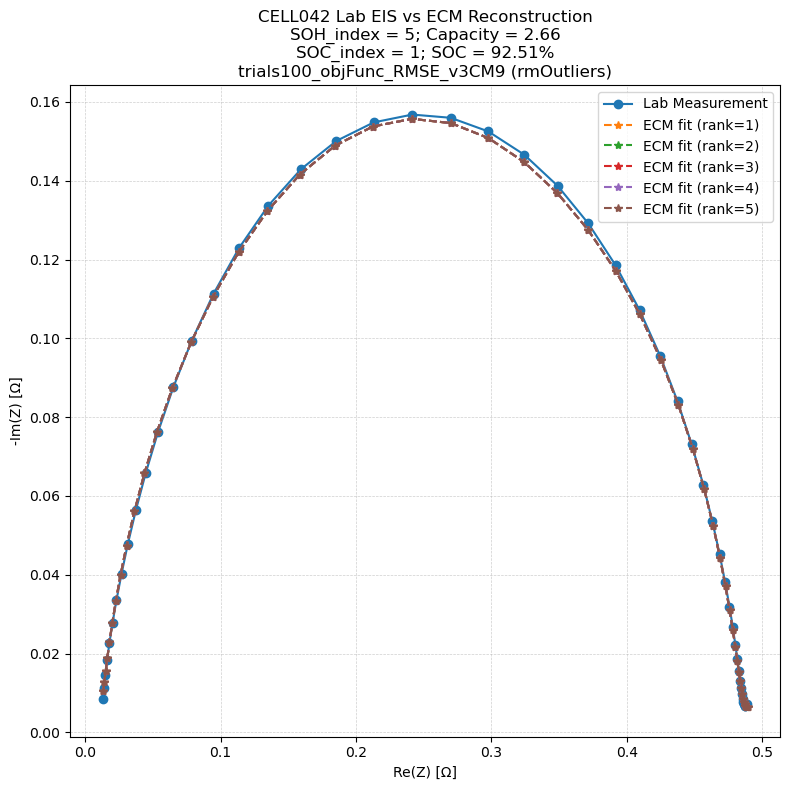

In [ ]:
CELL_NAME = "CELL042"
soh_label = 5
soc_label = 1
ECM_name = "v3CM9"
obj_func = "RMSE"
num_trials = 100

# ======================================================================== #
celli_metadata = BATTERY_METADATA[CELL_NAME]
celli_EISdata = BATTERY_EISDATA[CELL_NAME]

filepath = f"ECM_Params_Estimation/{CELL_NAME}/{ECM_name}_{obj_func}_trials{num_trials}/soh{soh_label}/{CELL_NAME}_soh{soh_label}_soc{soc_label}_trials{num_trials}_objFunc_{obj_func}_{ECM_name}_rmOutliers.csv"
subtitle = f"trials{num_trials}_objFunc_{obj_func}_{ECM_name} (rmOutliers)"

df = pd.read_csv(filepath)
select_ranks = df["trial_rank"].values
select_ranks = [1,2,3,4,5]

EIS_Nyquist_meas_vs_fit(CELL_NAME, celli_metadata, celli_EISdata, soh_label, soc_label, ECM_name, filepath, select_est_ranks=select_ranks, subtitle=subtitle)

## BOL & EOL boxplots -- per-parameter v.s SOC

functions:

In [45]:
def plot_param_boxplots(cell_name, bol_info, eol_info, param_name, num_trials=100, objFunc="RMSE", ECM_name="v3CM9"):
    """
    Create boxplots comparing BOL and EOL parameter distributions across SOC values.

    Parameters:
        cell_name (str): e.g., "C10"
        bol_info (list of tuples): [(soh_idx, [soc1, soc2, ...])]
        eol_info (list of tuples): [(soh_idx, [soc1, soc2, ...])]
        param_name (str): e.g., "R3"
    """
    data = []
    # Helper to read CSVs
    def collect_data(soh_type, info_list):
        for soh_label, soc_list in info_list:
            for soc_idx in range(len(soc_list)):
                file_name = f"ECM_Params_Estimation/{cell_name}/{ECM_name}_{objFunc}_trials{num_trials}/soh{soh_label}/{cell_name}_soh{soh_label}_soc{soc_idx+1}_trials{num_trials}_objFunc_{objFunc}_{ECM_name}_rmOutliers.csv"
                if not os.path.exists(file_name):
                    print(f"[Warning] Missing file: {file_name}")
                    continue
                df = pd.read_csv(file_name)
                df["SOH"] = soh_type
                df["SOC"] = round(soc_list[soc_idx] * 100, 2)
                data.append(df[["SOH", "SOC", param_name]])

    collect_data("BOL", bol_info)
    collect_data("EOL", eol_info)

    all_data = pd.concat(data, ignore_index=True)

    plt.figure(figsize=(12, 6))
    ax = sns.boxplot(
        data=all_data,
        x="SOC",
        y=param_name,
        hue="SOH",
        palette={"BOL": "skyblue", "EOL": "lightcoral"},
        showfliers=True
    )

    for i, artist in enumerate(ax.artists):
        if i % 2 == 0:  # BOL
            artist.set_edgecolor("blue")
        else:            # EOL
            artist.set_edgecolor("red")
        artist.set_linewidth(1.5)

    # ---- Compute medians for overlay ----
    median_data = all_data.groupby(["SOH", "SOC"], as_index=False)[param_name].median()

    # ---- Overlay median line ----
    sns.lineplot(
        data=median_data[median_data["SOH"] == "BOL"],
        x="SOC", y=param_name,
        color="blue", marker="o", markersize=6,
        linewidth=2.2, label="BOL Median", ax=ax
    )
    sns.lineplot(
        data=median_data[median_data["SOH"] == "EOL"],
        x="SOC", y=param_name,
        color="red", marker="o", markersize=6,
        linewidth=2.2, label="EOL Median", ax=ax
    )

    # ---- Labels and layout ----
    plt.title(f"{cell_name} BOL & EOL {param_name} vs SOC\n{ECM_name}_trials{num_trials}_rmOutliers")
    plt.xlabel("SOC (%)")
    plt.ylabel(param_name)
    plt.gca().invert_xaxis()
    plt.legend(title="SOH", loc="upper right")
    plt.tight_layout()
    plt.show()


In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

def plot_param_boxplots(cell_name, bol_info, eol_info, param_name, num_trials=100, objFunc="RMSE", ECM_name="v3CM9"):
    """
    Create boxplots comparing BOL and EOL parameter distributions across SOC values,
    with median points overlaid.
    """
    data = []

    # ---- Helper to read CSVs ----
    def collect_data(soh_type, info_list):
        for soh_label, soc_list in info_list:
            for soc_idx in range(len(soc_list)):
                file_name = f"ECM_Params_Estimation/{cell_name}/{ECM_name}_{objFunc}_trials{num_trials}/soh{soh_label}/{cell_name}_soh{soh_label}_soc{soc_idx+1}_trials{num_trials}_objFunc_{objFunc}_{ECM_name}_rmOutliers.csv"
                if not os.path.exists(file_name):
                    print(f"⚠️ Missing file: {file_name}")
                    continue
                df = pd.read_csv(file_name)
                df["SOH"] = soh_type
                df["SOC"] = round(soc_list[soc_idx] * 100, 2)
                data.append(df[["SOH", "SOC", param_name]])

    collect_data("BOL", bol_info)
    collect_data("EOL", eol_info)

    all_data = pd.concat(data, ignore_index=True)

    # ---- Draw boxplot ----
    plt.figure(figsize=(14, 6))
    ax = sns.boxplot(
        data=all_data,
        x="SOC",
        y=param_name,
        hue="SOH",
        palette={"BOL": "skyblue", "EOL": "lightcoral"},
        showfliers=True,
        width=0.6
    )

    # ---- Customize box borders ----
    for i, artist in enumerate(ax.artists):
        edge_color = "blue" if i % 2 == 0 else "red"
        artist.set_edgecolor(edge_color)
        artist.set_linewidth(1.8)
        # recolor whiskers, caps, medians
        for j in range(i * 6, i * 6 + 6):
            line = ax.lines[j]
            line.set_color(edge_color)
            line.set_mfc(edge_color)
            line.set_mec(edge_color)

    # ---- Compute medians ----
    median_data = all_data.groupby(["SOH", "SOC"], as_index=False)[param_name].median()

    # Prepare for alignment
    soc_unique = np.sort(all_data["SOC"].unique())
    positions = np.arange(len(soc_unique))
    offset = 0  # horizontal offset for hue separation

    # ---- Plot median points only ----
    for soh, color, dx, marker in zip(["BOL", "EOL"], ["blue", "red"], [-offset, offset], ["o", "o"]):
        sub = median_data[median_data["SOH"] == soh]
        xvals = [positions[np.where(soc_unique == s)[0][0]] + dx for s in sub["SOC"]]
        ax.scatter(xvals, sub[param_name], color=color, s=60, marker=marker, edgecolors="black", linewidths=1.0, zorder=5, label=f"{soh} Median")

    # ---- Adjust ticks ----
    ax.set_xticks(positions)
    ax.set_xticklabels([f"{s:.2f}" for s in soc_unique])
    ax.invert_xaxis()

    # ---- Title and layout ----
    plt.title(f"{cell_name} BOL & EOL \n{param_name} vs SOC\n{ECM_name}_trials{num_trials}_rmOutliers")
    plt.xlabel("SOC (%)")
    plt.ylabel(param_name)
    plt.legend(title="SOH", loc="best")
    plt.tight_layout()
    plt.grid(True, linestyle='--', color='lightgray', linewidth=0.7, alpha=0.8)
    plt.show()


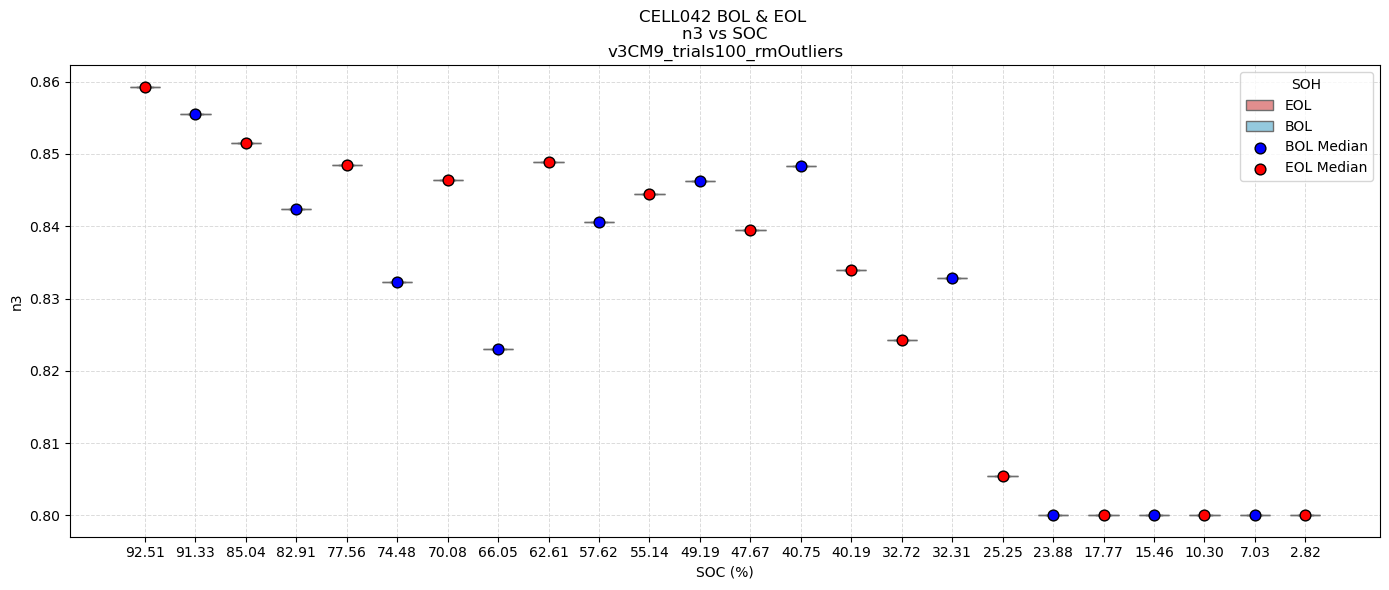

In [ ]:
CELL_NAME = "CELL042"
BOL_soh_label = 1
EOL_soh_label = 5
ECM_name = "v3CM9"
obj_func = "RMSE"
num_trials = 100
param_name = "n3"

# ======================================================================== #
BOL_soc_list = BATTERY_METADATA[CELL_NAME]["soh"][BOL_soh_label-1]["soc"]
EOL_soc_list = BATTERY_METADATA[CELL_NAME]["soh"][EOL_soh_label-1]["soc"]
bol_info = [(BOL_soh_label, BOL_soc_list)]
eol_info = [(EOL_soh_label, EOL_soc_list)]

plot_param_boxplots(CELL_NAME, bol_info, eol_info, param_name)

## BOL & EOL Line Plot -- per-parameter v.s SOC

Functions:

In [8]:
import pandas as pd
import numpy as np
import os

def process_drt_data(cell_name, bol_date, eol_date):
    """
    Process DRT data for a given cell and extract rows for BOL and EOL dates.
    """

    drt_csv = f"../EVC_EIS_Data/CELL_DRT_Data_11-3/data_{cell_name}.csv"
    if not os.path.exists(drt_csv):
        print(f"Warning: File not found: {drt_csv}")
        return {"BOL": pd.DataFrame(), "EOL": pd.DataFrame()}

    # Read and clean
    df = pd.read_csv(drt_csv)
    df.columns = df.columns.str.strip()
    df["date"] = df["date"].astype(str).str.strip()

    # Select relevant columns
    r_cols = [col for col in df.columns if col.startswith("R")]
    freq_cols = [f"ln_1_over_freq{i}" for i in range(1, 4)]
    keep_cols = ["date", "soc"] + r_cols + freq_cols
    df = df[keep_cols]

    # Convert ln_1_over_freq → freq = exp(-ln_1_over_freq)
    for i in range(1, 4):
        df[f"freq{i}"] = np.exp(-df[f"ln_1_over_freq{i}"])

    # Drop log columns
    df.drop(columns=freq_cols, inplace=True)

    # Add tau columns
    for i in range(1, 4):
        df[f"tau{i}"] = 1 /(2* np.pi* df[f"freq{i}"])

    # Filter by dates
    bol_df = df[df["date"] == bol_date].copy()
    eol_df = df[df["date"] == eol_date].copy()

    if bol_df.empty:
        print(f"Warning: No matching BOL data found for {bol_date} in {drt_csv}")
    if eol_df.empty:
        print(f"Warning: No matching EOL data found for {eol_date} in {drt_csv}")

    return {"BOL": bol_df, "EOL": eol_df}


In [2]:
def plot_param_summary_with_drt(cell_name, bol_info, eol_info, param_name, drt_data, num_trials=100, objFunc="RMSE", ECM_name="v3CM9"):
    """
    Create a line plot showing q1, median, q3, max, mean, and DRT value
    across concatenated SOC indices (BOL ↓ then EOL ↓).

    Parameters:
        drt_data (dict): Output from process_drt_data() — contains "BOL" and "EOL" DataFrames.
    """
    def collect_stats(soh_label, soc_list):
        stats = []
        for soc_idx, soc in enumerate(soc_list):
            file_name = (
                f"ECM_Params_Estimation/{cell_name}/"
                f"{ECM_name}_{objFunc}_trials{num_trials}/soh{soh_label}/"
                f"{cell_name}_soh{soh_label}_soc{soc_idx+1}_trials{num_trials}_"
                f"objFunc_{objFunc}_{ECM_name}_rmOutliers.csv"
            )
            if not os.path.exists(file_name):
                print(f"Warning: Missing file: {file_name}")
                continue

            df = pd.read_csv(file_name)
            values = df[param_name].dropna()
            stats.append({
                "soc": round(soc * 100, 2),
                "q1": np.percentile(values, 25),
                "median": np.median(values),
                "q3": np.percentile(values, 75),
                "max": np.max(values),
                "mean": np.mean(values)
            })
        return pd.DataFrame(stats)

    # Collect parameter statistics
    data_frames = []
    for soh_type, info_list in zip(["BOL", "EOL"], [bol_info, eol_info]):
        for soh_label, soc_list in info_list:
            df = collect_stats(soh_label, soc_list)
            df["SOH"] = soh_type
            data_frames.append(df)

    all_stats = pd.concat(data_frames, ignore_index=True)
    all_stats["index"] = np.arange(1, len(all_stats) + 1)

    # Merge DRT values
    drt_values = pd.concat([drt_data["BOL"][param_name], drt_data["EOL"][param_name]], ignore_index=True)
    all_stats["drt_value"] = drt_values.values[:len(all_stats)]

    # Plot
    plt.figure(figsize=(9, 5))
    plt.plot(all_stats["index"], all_stats["q1"], "-o", label="q1")
    plt.plot(all_stats["index"], all_stats["median"], "-o", label="median")
    plt.plot(all_stats["index"], all_stats["q3"], "-o", label="q3")
    plt.plot(all_stats["index"], all_stats["max"], "-o", label="max")
    plt.plot(all_stats["index"], all_stats["mean"], "-o", label="mean")
    plt.plot(all_stats["index"], all_stats["drt_value"], "-o", linewidth=2.2, label="DRT value")

    num_bol = len(bol_info[0][1])  # number of SOCs in BOL
    num_eol = len(eol_info[0][1])  # number of SOCs in EOL
    plt.title(f"{cell_name} BOL & EOL \n {param_name} Summary \n (BOL SOCs: {num_bol}, EOL SOCs: {num_eol})")
    plt.xlabel("SOC Index (BOL ↓ then EOL ↓)")
    plt.ylabel(param_name)
    plt.legend(title="Metric", loc="best")
    plt.grid(True, linestyle="--", color="lightgray", linewidth=0.7, alpha=0.8)
    plt.tight_layout()
    plt.xticks(np.arange(all_stats["index"].min(), all_stats["index"].max() + 1, 1))
    plt.show()


In [3]:
def print_freq_comparison(cell_name, soh_idx, soc_idx, date, ECM_name="v3CM9", objFunc="RMSE", num_trials=100):
    """
    Print ECM and DRT frequency (freq1–freq3) values for a given cell, SOH index, SOC index, and date.

    Parameters:
        cell_name (str): e.g., "CELL042"
        soh_idx (int): SOH index (e.g. 1 for BOL, 2 for EOL)
        soc_idx (int): SOC index (1-based)
        date (str): Date in DRT CSV (e.g. '20220916' or '20231011')
        ECM_name (str): ECM model name (default: 'v3CM9')
        objFunc (str): Objective function (default: 'RMSE')
        num_trials (int): Number of ECM estimation trials (default: 100)
    """

    # === ECM frequency ===
    ecm_file = f"ECM_Params_Estimation/{cell_name}/{ECM_name}_{objFunc}_trials{num_trials}/soh{soh_idx}/{cell_name}_soh{soh_idx}_soc{soc_idx}_trials{num_trials}_objFunc_{objFunc}_{ECM_name}_rmOutliers.csv"

    if not os.path.exists(ecm_file):
        print(f"Warning: ECM file not found:\n  {ecm_file}")
        ecm_freqs = None
    else:
        df_ecm = pd.read_csv(ecm_file)
        # Take mean of 100 trials for stable estimate
        ecm_freqs = df_ecm[['freq1', 'freq2', 'freq3']].mean().round(3).to_dict()
        ecm_taus = df_ecm[['tau1', 'tau2', 'tau3']].mean().to_dict()

    # === DRT frequency ===
    drt_csv = f"../EVC_EIS_Data/CELL_DRT_Data/data_{cell_name}.csv"
    if not os.path.exists(drt_csv):
        print(f"Warning: DRT file not found:\n  {drt_csv}")
        drt_freqs = None
    else:
        df_drt = pd.read_csv(drt_csv)
        df_drt.columns = df_drt.columns.str.strip()
        df_drt["date"] = df_drt["date"].astype(str).str.strip()

        # Filter by date
        drt_date_df = df_drt[df_drt["date"] == date].copy()
        if drt_date_df.empty:
            print(f"Warning: No matching DRT data found for date {date}")
            drt_freqs = None
        else:
            # Convert ln_1_over_freq → freq
            for i in range(1, 4):
                drt_date_df[f"freq{i}"] = np.exp(-drt_date_df[f"ln_1_over_freq{i}"])
            try:
                drt_freqs = drt_date_df.iloc[soc_idx - 1][["freq1", "freq2", "freq3"]].round(3).to_dict()
                drt_taus = {k: 1 / v for k, v in drt_freqs.items()}
            except IndexError:
                print(f"⚠️ Invalid SOC index {soc_idx} for DRT data on {date}")
                drt_freqs = None

    # === Print results ===
    print(f"\n Frequency comparison for {cell_name} | SOH {soh_idx} | SOC {soc_idx} | Date {date}")
    print("-" * 70)
    if ecm_freqs:
        print(f"ECM ({ECM_name}): freq1={ecm_freqs['freq1']}, freq2={ecm_freqs['freq2']}, freq3={ecm_freqs['freq3']}")
        print(f"tau1={ecm_taus['tau1']}, tau2={ecm_taus['tau2']}, tau2={ecm_taus['tau3']}")
    else:
        print("ECM data not available.")
    if drt_freqs:
        print(f"DRT ({date}): freq1={drt_freqs['freq1']}, freq2={drt_freqs['freq2']}, freq3={drt_freqs['freq3']}")
        print(f"DRT ({date}): tau1={drt_taus['freq1']}, tau2={drt_taus['freq2']}, tau3={drt_taus['freq3']}")
    else:
        print("DRT data not available.")

Plot Usage:

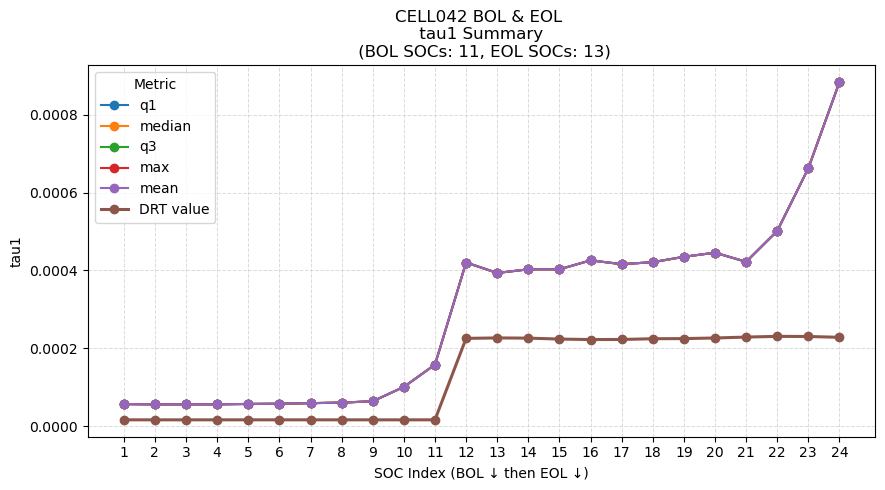

In [11]:
CELL_NAME = "CELL042"
BOL_soh_label = 1
EOL_soh_label = 5
ECM_name = "v3CM9"
obj_func = "RMSE"
num_trials = 100
param_name = "tau1"

# ======================================================================== #
BOL_date = BATTERY_METADATA[CELL_NAME]["soh"][BOL_soh_label-1]["date"]
EOL_date = BATTERY_METADATA[CELL_NAME]["soh"][EOL_soh_label-1]["date"]
BOL_soc_list = BATTERY_METADATA[CELL_NAME]["soh"][BOL_soh_label-1]["soc"]
EOL_soc_list = BATTERY_METADATA[CELL_NAME]["soh"][EOL_soh_label-1]["soc"]
bol_info = [(BOL_soh_label, BOL_soc_list)]
eol_info = [(EOL_soh_label, EOL_soc_list)]

# Process drt data for selected BOL and EOL
drt_data = process_drt_data(CELL_NAME, BOL_date, EOL_date)

# Plot
plot_param_summary_with_drt(CELL_NAME, bol_info, eol_info, param_name, drt_data)

Print freqs:

In [12]:
# For BOL
print_freq_comparison("CELL042", soh_idx=1, soc_idx=1, date="20220916")

# For EOL
print_freq_comparison("CELL042", soh_idx=2, soc_idx=1, date="20231011")



 Frequency comparison for CELL042 | SOH 1 | SOC 1 | Date 20220916
----------------------------------------------------------------------
ECM (v3CM9): freq1=2822.408, freq2=648.643, freq3=85.378
tau1=5.638977224225284e-05, tau2=0.00024536617588900834, tau2=0.0018641163848815729
DRT (20220916): freq1=10001.000827739348, freq2=708.0305919778567, freq3=184.29268382474697
DRT (20220916): tau1=9.998999272416244e-05, tau2=0.0014123683514952903, tau3=0.005426151376421158

 Frequency comparison for CELL042 | SOH 2 | SOC 1 | Date 20231011
----------------------------------------------------------------------
ECM (v3CM9): freq1=1704.303, freq2=376.341, freq3=92.952
tau1=9.338418318149182e-05, tau2=0.0004229004867083031, tau2=0.0017122351269847926
DRT (20231011): freq1=706.0898536089475, freq2=160.99095795095343, freq3=8.691678765131014
DRT (20231011): tau1=0.0014162503467353722, tau2=0.006211528974842514, tau3=0.11505257235365929


## Parameter Value v.s SOC for all SOH all CELL

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# === Load CSV ===
DRT = True

if DRT:
    df = pd.read_csv("drtdf_date_allSOC.csv")
else:
    df = pd.read_csv("fulldf_global_date_allSOC_all.csv")

# === Compute tau values ===
def compute_time_constant(R, Q, n):
    try:
        if R <= 0 or Q <= 0 or n <= 0:
            return np.inf
        return (R * Q) ** (1 / n)
    except (ZeroDivisionError, FloatingPointError):
        return np.inf

# # Hardcode for Circuit Model v3CM9
# if not DRT:
#     df["tau1"] = df.apply(lambda row: compute_time_constant(row["R1"], row["C1"], row["n1"]), axis=1)
#     df["tau2"] = df.apply(lambda row: compute_time_constant(row["R2"], row["C2"], row["n2"]), axis=1)
#     df["tau3"] = df.apply(lambda row: compute_time_constant(row["R3"], row["C3"], row["n3"]), axis=1)

# === List of parameters to plot ===
if DRT:
    params = ["R0", "R1", "R2", "R3", "tau1", "tau2", "tau3"]
else:
    params = ["R0", "R1", "R2", "R3",
            "C1", "n1", "C2", "n2", "C3", "n3",
            "Aw", "tau1", "tau2", "tau3"]


# === Ensure output directory ===
save_dir = "CELL_Param_SOC_plots"
os.makedirs(save_dir, exist_ok=True)

# df cleaning, convert to numeric
if DRT:
    numeric_cols = ["R0","R1","R2","R3",
                    "tau1","tau2","tau3",
                    "SOC","SOH","Temp"]
else: 
    numeric_cols = ["R0","R1","R2","R3",
                    "C1","n1","C2","n2","C3","n3",
                    "Aw","tau1","tau2","tau3",
                    "SOC","SOH","Temp"]


for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

###   Datafram Debug  ###
# inf_rows = df[np.isinf(df[numeric_cols]).any(axis=1)]
# print("Rows containing +inf or -inf:")
# print(inf_rows)



# params = ["R0", "R1", "R2", "R3",
#           "C1", "n1", "C2", "n2", "C3", "n3",
#           "Aw", "tau1", "tau2", "tau3"]
# print("=== Starting yerr diagnostics ===")
# for date_val, df_date in df.groupby("date"):
#     # Compute per-SOC stats
#     agg = df_date.groupby("SOC")[params].agg(["mean", "min", "max"])
#     agg.columns = ['_'.join(col).strip() for col in agg.columns.values]
#     agg = agg.reset_index()
#     # Loop through all parameters
#     for p in params:
#         mean_col = f"{p}_mean"
#         min_col  = f"{p}_min"
#         max_col  = f"{p}_max"
#         if mean_col not in agg or min_col not in agg or max_col not in agg:
#             print(f"⚠️ Missing columns for {p} on date {date_val}")
#             continue
#         # Compute yerr
#         lower = agg[mean_col] - agg[min_col]
#         upper = agg[max_col] - agg[mean_col]
#         # Find invalid cases
#         bad_rows = agg[(lower < 0) | (upper < 0)]

#         if not bad_rows.empty:
#             print("\n🚨 NEGATIVE yerr detected!")
#             print(f"Date: {date_val}, Parameter: {p}")
#             print("Problematic rows:")
#             print(bad_rows[["SOC", mean_col, min_col, max_col]])
#             print("----")

target_params = ["R0", "R1", "R2", "R3"]
plot_param_scale = {
    "R0": (0.0055, 0.014),
    "R1": (0.002, 0.35),
    "R2": (0.002, 0.35),
    "R3": (0.002, 0.18),
}

target_params = ["R0", "R1", "R2", "R3", "tau1", "tau2", "tau3"]

# === Iterate by CELL ===
for cell in df["CELL"].unique():
    print(f"Plotting for {cell}")
    df_cell = df[df["CELL"] == cell]
    plot_dir = os.path.join(save_dir, str(cell))
    os.makedirs(plot_dir, exist_ok=True)

    for param in target_params:
        plt.figure(figsize=(8, 5))

        # === Group by DATE ===
        for date_val, df_date in df_cell.groupby("date"):
            soh_val = df_date["SOH"].iloc[0]

            # Aggregate stats per SOC
            agg = df_date.groupby("SOC")[param].agg(["mean", "min", "max"]).reset_index()
            
            # === Rename columns to param_mean, param_min, param_max ===
            agg.rename(columns={
                "mean": f"{param}_mean",
                "min": f"{param}_min",
                "max": f"{param}_max"
            }, inplace=True)


            # --- Plot mean curve ---
            line,  = plt.plot(
                agg["SOC"], agg[f"{param}_mean"],
                marker="o", linestyle="-",
                label=f"{date_val} — SOH={soh_val:.4f}",
                alpha=0.9
            )
            line_color = line.get_color()

            # --- Plot min/max as vertical error bars ---
            lower_err = (agg[param + "_mean"] - agg[param + "_min"])
            upper_err = (agg[param + "_max"] - agg[param + "_mean"])

            # Remove tiny negative errors caused by float precision 
            # (this was very tricky and finally found out the issue)
            lower_err = lower_err.clip(lower=0).fillna(0)
            upper_err = upper_err.clip(lower=0).fillna(0)

            plt.errorbar(
                agg["SOC"], agg[param + "_mean"],
                yerr=[lower_err, upper_err],
                fmt="none", alpha=0.45, capsize=3, color=line_color
            )

            # # --- Plot raw points (real data only) ---
            # plt.scatter(
            #     df_date["SOC"], df_date[param],
            #     s=12, alpha=0.3, color="black"
            # )

        plt.title(f"{param} vs SOC — CELL {cell}")
        plt.xlabel("SOC")
        plt.ylabel(param)
        plt.xticks(np.arange(0, 1.1, 0.1))
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.legend(title="Date — SOH")
        plt.tight_layout()
        # plt.ylim(plot_param_scale[param])

        plt.savefig(os.path.join(plot_dir, f"{param}.png"), dpi=300)
        plt.close()

print("All plots saved in 'CELL_Param_SOC_plots/' directory.")


Plotting for CELL042
Plotting for CELL050
Plotting for CELL090
Plotting for CELL013
Plotting for CELL045
Plotting for CELL054
Plotting for CELL076
Plotting for CELL096
Plotting for CELL009
Plotting for CELL021
Plotting for CELL077
Plotting for CELL070
Plotting for CELL101


c:\Users\liuha\miniconda3\envs\EIS\Lib\site-packages\matplotlib\cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
c:\Users\liuha\miniconda3\envs\EIS\Lib\site-packages\matplotlib\cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
c:\Users\liuha\miniconda3\envs\EIS\Lib\site-packages\matplotlib\cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
c:\Users\liuha\miniconda3\envs\EIS\Lib\site-packages\matplotlib\cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


Plotting for CELL032
All plots saved in 'CELL_Param_SOC_plots/' directory.


Plot DRT and ECM Data together for comparison:

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np


# ================================================================
#  Load DataFrames
# ================================================================
# df_drt  = DRT data (with R, tau)
# df_ecm  = ECM data (with R, C, n, tau, etc.)
# ================================================================

df_drt = pd.read_csv("drtdf_date_allSOC.csv")
df_ecm = pd.read_csv("fulldf_global_date_allSOC_all.csv")

#NOTE: only 25
# Convert Temp to numeric just in case
df_drt["Temp"] = pd.to_numeric(df_drt["Temp"], errors="coerce")
df_ecm["Temp"] = pd.to_numeric(df_ecm["Temp"], errors="coerce")
df_drt = df_drt[df_drt["Temp"] == 25].reset_index(drop=True)
df_ecm = df_ecm[df_ecm["Temp"] == 25].reset_index(drop=True)


# Normalize DRT date
df_drt["date"] = (
    df_drt["date"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.strip()
    .str.zfill(8)
)

# Normalize ECM date
df_ecm["date"] = (
    df_ecm["date"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.strip()
    .str.zfill(8)
)

# Set this if needed:
save_dir = "CELL_Param_SOC_plots_DRTvsECM_sameScale"
os.makedirs(save_dir, exist_ok=True)


# ================================================================
#  Convert important columns to numeric
# ================================================================
numeric_cols = [
    "R0","R1","R2","R3","tau1","tau2","tau3","SOC","SOH","Temp"
]

for col in numeric_cols:
    if col in df_drt.columns:
        df_drt[col] = pd.to_numeric(df_drt[col], errors="coerce")
    if col in df_ecm.columns:
        df_ecm[col] = pd.to_numeric(df_ecm[col], errors="coerce")


# ================================================================
# Parameters to Plot
# ================================================================
target_params = ["R0", "R1", "R2", "R3", "tau1", "tau2", "tau3"]



# ================================================================
#  Helper: Aggregation by SOC
# ================================================================
def compute_soc_aggregates(df, param):
    agg = df.groupby("SOC")[param].agg(["mean", "min", "max"]).reset_index()
    agg.rename(columns={
        "mean": f"{param}_mean",
        "min":  f"{param}_min",
        "max":  f"{param}_max"
    }, inplace=True)
    return agg

# ============================================================
# Compute GLOBAL y-limits for each parameter
# ============================================================
params_ylims = {}

for param in target_params:
    # Combine DRT + ECM values for this param
    vals = pd.concat([df_drt[param], df_ecm[param]], axis=0)
    vals = vals.replace([np.inf, -np.inf], np.nan).dropna()

    if len(vals) == 0:
        continue

    vmin = vals.min()
    vmax = vals.max()

    # Add padding (10% on each side)
    pad = 0.1 * (vmax - vmin)
    if pad == 0:
        pad = 0.01 * abs(vmax)

    params_ylims[param] = (vmin - pad, vmax + pad)

print("Global per-parameter y-limits:")
for p, lim in params_ylims.items():
    print(f"{p}: {lim}")


# ================================================================
#  Main Combined Plotting Loop
# ================================================================
all_cells = sorted(set(df_drt["CELL"]) | set(df_ecm["CELL"]))

# === Iterate by CELL ===
for cell in sorted(set(df_drt["CELL"]) | set(df_ecm["CELL"])):
    print(f"Plotting for CELL {cell}")

    df_d = df_drt[df_drt["CELL"] == cell].copy()
    df_e = df_ecm[df_ecm["CELL"] == cell].copy()

    plot_dir = os.path.join(save_dir, str(cell))
    os.makedirs(plot_dir, exist_ok=True)

    # =======================================================
    # Build unified date list & assign consistent colors
    # =======================================================
    all_dates = sorted(set(df_d["date"]) | set(df_e["date"]))
    cmap = plt.get_cmap("tab10")   # nice discrete colors
    date_to_color = {d: cmap(i % 10) for i, d in enumerate(all_dates)}

    for param in target_params:
        plt.figure(figsize=(8, 5))

        # =======================================================
        # ECM — solid lines
        # =======================================================
        for date_val, df_date in df_e.groupby("date"):
            if df_date.empty:
                continue
            color = date_to_color[date_val]
            soh_val = df_date["SOH"].iloc[0]

            agg = df_date.groupby("SOC")[param].agg(["mean", "min", "max"]).reset_index()
            agg.rename(columns={"mean": f"{param}_mean",
                                "min": f"{param}_min",
                                "max": f"{param}_max"}, inplace=True)

            line, = plt.plot(
                agg["SOC"], agg[f"{param}_mean"],
                marker="o",
                linestyle="-",
                color=color,
                label=f"ECM — {date_val} (SOH={soh_val:.4f})",
                alpha=0.9
            )

            # lower = (agg[f"{param}_mean"] - agg[f"{param}_min"]).clip(lower=0)
            # upper = (agg[f"{param}_max"] - agg[f"{param}_mean"]).clip(lower=0)

            # plt.errorbar(
            #     agg["SOC"], agg[f"{param}_mean"],
            #     yerr=[lower, upper],
            #     fmt="none", color=color, alpha=0.45, capsize=3
            # )

        # =======================================================
        # DRT — dashed lines (same color)
        # =======================================================
        for date_val, df_date in df_d.groupby("date"):
            if df_date.empty:
                continue
            color = date_to_color[date_val]
            soh_val = df_date["SOH"].iloc[0]

            agg = df_date.groupby("SOC")[param].agg(["mean", "min", "max"]).reset_index()
            agg.rename(columns={"mean": f"{param}_mean",
                                "min": f"{param}_min",
                                "max": f"{param}_max"}, inplace=True)

            line, = plt.plot(
                agg["SOC"], agg[f"{param}_mean"],
                marker="s",
                linestyle="--",       # <-- dashed for DRT
                color=color,
                label=f"DRT — {date_val} (SOH={soh_val:.4f})",
                alpha=0.85
            )

            # lower = (agg[f"{param}_mean"] - agg[f"{param}_min"]).clip(lower=0)
            # upper = (agg[f"{param}_max"] - agg[f"{param}_mean"]).clip(lower=0)

            # plt.errorbar(
            #     agg["SOC"], agg[f"{param}_mean"],
            #     yerr=[lower, upper],
            #     fmt="none", color=color, alpha=0.35, capsize=3
            # )

        # =======================================================
        # Layout and save
        # =======================================================
        plt.title(f"{param} vs SOC — CELL {cell}")
        plt.xlabel("SOC")
        plt.ylabel(param)
        plt.xticks(np.arange(0, 1.1, 0.1))
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.legend(title="Model — Date — SOH")
        plt.tight_layout()
        if param in params_ylims:
            plt.ylim(params_ylims[param])

        plt.savefig(os.path.join(plot_dir, f"{param}.png"), dpi=300)
        plt.close()

print(f"All plots saved in '{save_dir}' directory.")



Global per-parameter y-limits:
R0: (0.0029351505274820794, 0.03833888699072272)
R1: (-0.04149569904421095, 0.45819084174376246)
R2: (-0.03476721976136466, 0.38671666011107647)
R3: (-0.01828150725837399, 0.2032820796620335)
tau1: (-9.956874264733454e-05, 0.0012862229158072485)
tau2: (-0.0005260286739961628, 0.006219557113257615)
tau3: (-0.01307258990693703, 0.14502052495084053)
Plotting for CELL CELL013
Plotting for CELL CELL042
Plotting for CELL CELL045
Plotting for CELL CELL050
Plotting for CELL CELL054
Plotting for CELL CELL076
Plotting for CELL CELL090
Plotting for CELL CELL096
All plots saved in 'CELL_Param_SOC_plots_DRTvsECM_sameScale' directory.


## Parameter Value v.s. SOH (SOC shaded)

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.cm import ScalarMappable

# === SOC shading colormap (light → dark) ===
soc_cmap = plt.cm.Blues

# === Load CSV ===
df = pd.read_csv("fulldf_global_date_G25SOC_all.csv")
df = df[df["Temp"] == 25]

# Sort unique cells for consistent ordering
unique_cells = sorted(df["CELL"].unique())

# Assign tab10 colors to cells
tab10_colors = plt.cm.tab10(np.linspace(0, 1, 10))
cell_color_map = {
    cell: tab10_colors[i % 10][:3] for i, cell in enumerate(unique_cells)
}
print("Base colors per cell:", cell_color_map)

save_dir_scatter = "CELL_Param_SOH_scatter_plots"
os.makedirs(save_dir_scatter, exist_ok=True)

for param in target_params:   # ["R0","R1","R2","R3"]
    plt.figure(figsize=(8, 6))

    for cell in unique_cells:
        df_cell = df[df["CELL"] == cell]

        # Compute mean param per (SOH, SOC)
        agg = (
            df_cell.groupby(["SOH", "SOC"])[param]
            .mean()
            .reset_index()
            .rename(columns={param: f"{param}_mean"})
        )

        # Identify highest SOC
        max_soc = agg["SOC"].max()
        base_color = cell_color_map[cell]   # this is now "highest SOC" color

        # Normalize SOC for shading
        soc_norm = (agg["SOC"] - agg["SOC"].min()) / (agg["SOC"].max() - agg["SOC"].min() + 1e-12)
        soc_shaded_colors = soc_cmap(soc_norm)

        # Mix highest SOC color with SOC shading
        final_colors = []
        for i in range(len(agg)):
            shade = soc_shaded_colors[i][:3]
            # Blend so that high SOC = base color
            w = soc_norm[i]            # weight increases with SOC
            final = w * np.array(base_color) + (1 - w) * np.array(shade)
            final_colors.append(final)

        plt.scatter(
            agg["SOH"],
            agg[f"{param}_mean"],
            s=40,
            color=final_colors,
            alpha=0.95
        )

    # === Legend uses ONLY base colors (highest SOC) ===
    legend_handles = []
    for cell in unique_cells:
        legend_handles.append(
            plt.Line2D(
                [0], [0],
                marker="o",
                linestyle="",
                markersize=8,
                markerfacecolor=cell_color_map[cell],
                markeredgecolor="black",
                label=str(cell)
            )
        )

    plt.legend(
        handles=legend_handles,
        title="CELL (base color = highest SOC)",
        bbox_to_anchor=(1.04, 1),
        loc="upper left",
        borderpad=0.8
    )

    plt.xlabel("SOH")
    plt.ylabel(param)
    plt.title(f"{param} vs SOH (SOC shading, tab10 base color = highest SOC) \n SOC>25%")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()

    plt.savefig(os.path.join(save_dir_scatter, f"{param}_SOH_scatter.png"), dpi=300, bbox_inches="tight")
    plt.close()

print("Scatter plots saved under 'CELL_Param_SOH_scatter_plots/'")


Base colors per cell: {'CELL013': array([0.12156863, 0.46666667, 0.70588235]), 'CELL042': array([1.        , 0.49803922, 0.05490196]), 'CELL045': array([0.17254902, 0.62745098, 0.17254902]), 'CELL050': array([0.83921569, 0.15294118, 0.15686275]), 'CELL054': array([0.58039216, 0.40392157, 0.74117647]), 'CELL076': array([0.54901961, 0.3372549 , 0.29411765]), 'CELL090': array([0.89019608, 0.46666667, 0.76078431]), 'CELL096': array([0.49803922, 0.49803922, 0.49803922])}
Scatter plots saved under 'CELL_Param_SOH_scatter_plots/'


Plotly version:

In [8]:
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd
import os

DRT = True
# === Load and filter data ===
df = pd.read_csv("fulldf_global_date_G25SOC_all.csv")
if DRT:
    df = pd.read_csv("drtdf_date_G25SOC.csv")

df = df[df["Temp"] == 25]
target_params = ["R0", "R1", "R2", "R3"]
unique_cells = sorted(df["CELL"].unique())

# === Assign tab10 colors to cells ===
tab10_colors = px.colors.qualitative.T10
cell_color_map = {
    cell: tab10_colors[i % 10] for i, cell in enumerate(unique_cells)
}

save_dir_plotly = "CELL_Param_SOH_plotly"
if DRT:
    save_dir_plotly = "CELL_Param_SOH_plotly_DRT"

os.makedirs(save_dir_plotly, exist_ok=True)

# Compute aggregated means per (CELL, SOH, SOC)
df_agg = (
    df.groupby(["CELL", "SOH", "SOC"])[target_params]
      .mean()
      .reset_index()
)

# Normalize SOC for shading (0 → 1)
soc_norm = (df_agg["SOC"] - df_agg["SOC"].min()) / (df_agg["SOC"].max() - df_agg["SOC"].min())
df_agg["soc_norm"] = soc_norm

# Expand back to RGB shading for each CELL
def blend_colors(base_hex, w):
    """Blend base color with white using SOC weight"""
    base_rgb = np.array([int(base_hex[i:i+2], 16) for i in (1, 3, 5)]) / 255.0
    white = np.array([1, 1, 1])
    blended = w * base_rgb + (1-w) * white
    return f"rgb({int(blended[0]*255)}, {int(blended[1]*255)}, {int(blended[2]*255)})"

for param in target_params:  # ["R0", "R1", "R2", "R3"]
    fig = go.Figure()

    for cell in unique_cells:
        df_cell = df_agg[df_agg["CELL"] == cell].copy()

        # Base color = tab10 color for highest SOC
        base_hex = cell_color_map[cell]
        
        # Compute blended color for each SOC point
        df_cell["color"] = df_cell["soc_norm"].apply(lambda w: blend_colors(base_hex, w))
       
        # Fake point for legend purpose
        fig.add_trace(
            go.Scatter(
                x=[None], y=[None],
                mode="markers",
                marker=dict(
                    size=10,
                    color=base_hex,    # pure tab10 color for legend
                    line=dict(width=0.5, color="black")
                ),
                name=f"CELL {cell}",
                showlegend=True
            )
        )
        
        # Add trace
        fig.add_trace(
            go.Scatter(
                x=df_cell["SOH"],
                y=df_cell[param],
                mode="markers",
                marker=dict(
                    size=10,
                    color=df_cell["color"],
                    line=dict(width=0.5, color="black")       
                ),
                name=f"CELL {cell}",
                showlegend=False,   # DO NOT show in legend
                hovertemplate = (
                    f"""
                    CELL: %{{customdata[0]}}<br>
                    SOH: %{{x:.4f}}<br>
                    SOC: %{{customdata[1]:.4f}}<br>
                    {param}: %{{y:.6f}}
                    <extra></extra>
                    """
                ),
                customdata=np.stack([df_cell["CELL"], df_cell["SOC"]], axis=-1)
            )
        )

    # Layout
    fig.update_layout(
        title=f"{param} vs SOH (interactive, shaded by SOC) \n SOC>25%",
        xaxis_title="SOH",
        yaxis_title=param,
        width=900,
        height=600,
        legend_title="CELL (base color = highest SOC)",
        template="plotly_white"
    )

    # Save as interactive HTML
    fig.write_html(os.path.join(save_dir_plotly, f"{param}_SOH_interactive.html"))

print(f" All interactive Plotly figures saved under '{save_dir_plotly}'")


 All interactive Plotly figures saved under 'CELL_Param_SOH_plotly_DRT'
